In [5]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, nltk, os, glob
from utils import plot_style, norm01; plot_style();
import torch

### Objective
* Generate one-hot stimulus vector of stim_dim per timepoint across total_time
* event structure: n_events = 10; event_avg_len = total_time/n_events (+noise across events, but ensuring total timepoints dont surpass total_time). Random event order.
* within each event, stimuli should be autoregressive, i.e., directedly autocorrelated; for example
    * 1010, 1000, 0000 across event 1 with stim_dim=4 and event_avg_len[event_i] = 3, where,
    * autoreg_feat_size[event_i] = 3, autoreg_features[event_i] = [0,1,2] because those dimensions seems to change progressively; and
    * autoreg_direction[event_i] = 0 because 1s become 0s
    * Thoughts? Better ways to operationalize autoregression?
* visualize time-time stim correlation heatmap in my plotting code style

In [6]:

# Parameters
np.random.seed(42)
stim_dim   = 10
total_time = 500
n_events   = 10
event_avg_len = total_time // n_events

# Variable event lengths with noise; last event adjusted to hit total_time exactly
event_lengths = np.random.normal(event_avg_len, event_avg_len * 0.2, n_events).astype(int)
event_lengths = np.clip(event_lengths, 1, None)
event_lengths[-1] = total_time - event_lengths[:-1].sum()

event_order = np.random.permutation(n_events)

print(f"stim_dim={stim_dim}, total_time={total_time}, n_events={n_events}")
print(f"event_lengths: {event_lengths}  (sum={event_lengths.sum()})")
print(f"event_order:   {event_order}")


stim_dim=10, total_time=500, n_events=10
event_lengths: [54 48 56 65 47 47 65 57 45 16]  (sum=500)
event_order:   [6 2 8 7 9 5 1 3 0 4]


In [10]:

# Per-event autoregressive metadata
autoreg_features  = []  # which feature indices are autoregressive per event
autoreg_direction = []  # 0=decay (1→0), 1=build (0→1) per event

for event_idx in range(n_events):
    n_autoreg = np.random.randint(5, min(6, stim_dim + 1))
    feat_order = np.random.permutation(stim_dim)[:n_autoreg]
    autoreg_features.append(feat_order)
    autoreg_direction.append(np.random.randint(0, 2))

autoreg_direction = np.array(autoreg_direction)

for i in range(n_events):
    label = "build (0→1)" if autoreg_direction[i] == 1 else "decay (1→0)"
    print(f"Event {i:2d}: autoreg_feats={autoreg_features[i]}  direction={label}")


Event  0: autoreg_feats=[4 1 8 2 0]  direction=build (0→1)
Event  1: autoreg_feats=[9 2 7 3 4]  direction=decay (1→0)
Event  2: autoreg_feats=[7 0 3 5 8]  direction=build (0→1)
Event  3: autoreg_feats=[9 8 1 5 2]  direction=decay (1→0)
Event  4: autoreg_feats=[6 2 1 8 5]  direction=decay (1→0)
Event  5: autoreg_feats=[2 1 3 5 4]  direction=decay (1→0)
Event  6: autoreg_feats=[3 8 9 1 4]  direction=build (0→1)
Event  7: autoreg_feats=[1 3 8 4 9]  direction=decay (1→0)
Event  8: autoreg_feats=[9 2 5 8 1]  direction=build (0→1)
Event  9: autoreg_feats=[4 6 1 3 2]  direction=build (0→1)


In [11]:

# Generate stimulus matrix with autoregressive event structure
stim = np.zeros((total_time, stim_dim))
feat_ptr = 0  # running timepoint pointer

for event_order_idx in event_order:
    event_len      = event_lengths[event_order_idx]
    autoreg_feats  = autoreg_features[event_order_idx]
    direction      = autoreg_direction[event_order_idx]
    non_autoreg    = np.setdiff1d(np.arange(stim_dim), autoreg_feats)

    for step in range(event_len):
        t = feat_ptr + step
        progress = step / (event_len - 1) if event_len > 1 else 0.5

        # Autoregressive features: smooth linear fade
        if direction == 0:          # decay: 1 → 0
            stim[t, autoreg_feats] = 1.0 - progress
        else:                       # build: 0 → 1
            stim[t, autoreg_feats] = progress

        # Non-autoregressive features: random sparse (Bernoulli 0.5)
        stim[t, non_autoreg] = (np.random.rand(len(non_autoreg)) > 0.5).astype(float)

    feat_ptr += event_len

print(f"stim shape : {stim.shape}")
print(f"stim range : [{stim.min():.2f}, {stim.max():.2f}]")
print(f"Total timepoints filled: {feat_ptr}")


stim shape : (500, 10)
stim range : [0.00, 1.00]
Total timepoints filled: 500


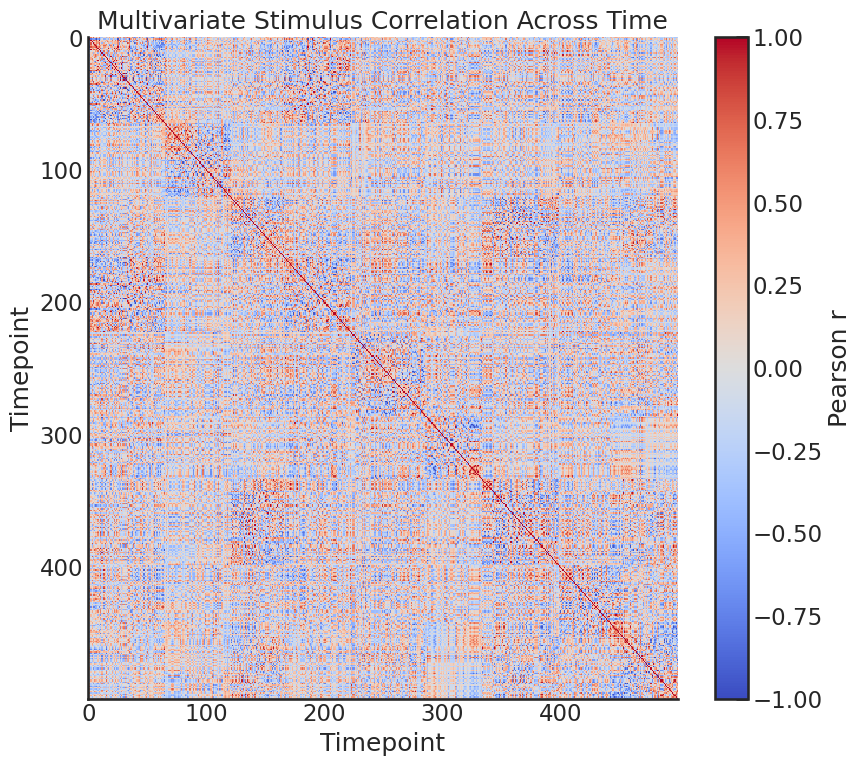

In [12]:

# Multivariate stimulus correlation across time
corr = np.corrcoef(stim)   # (total_time × total_time)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1,
               origin='upper', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_xlabel('Timepoint')
ax.set_ylabel('Timepoint')
ax.set_title('Multivariate Stimulus Correlation Across Time')
plt.tight_layout()
plt.show()
